# Melanogenesis Network Constraint Analysis

This notebook analyzes genetic constraint (LOEUF) across genes in the melanogenesis pathway, examining whether constraint patterns differ by:
1. **Functional category** (pigment-specific vs generic signaling vs developmental)
2. **Disease phenotype** (syndromic/multi-system vs isolated pigmentation)

## Data Sources
- **Raghunath et al. 2015** (BMC Research Notes): Melanocyte signaling network with pre-computed centrality metrics
- **gnomAD v2.1.1**: LOEUF (loss-of-function observed/expected upper bound fraction)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import gzip
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

print("Packages loaded successfully")

Packages loaded successfully


## 1. Configure File Paths

**Required files:**
1. Raghunath et al. 2015 supplementary file: Download from https://doi.org/10.1186/s13104-015-1128-6
2. gnomAD v2.1.1 constraint file: Download from https://gnomad.broadinstitute.org/downloads#v2-constraint
   - Either `gnomad.v2.1.1.lof_metrics.by_gene.txt.bgz` OR
   - `gnomad.v2.1.1.lof_metrics.by_transcript.txt.bgz` (this notebook handles both)

In [5]:
# ============================================================
# CONFIGURE YOUR FILE PATHS HERE
# ============================================================

# Path to Raghunath supplementary Excel file
RAGHUNATH_FILE = '../data/13104_2015_1128_MOESM2_ESM.xlsx'

# Path to gnomAD constraint file (bgz compressed)
# Works with either by_gene or by_transcript file
GNOMAD_FILE = '../data/gnomad_constraint.txt.bgz'

# Output directory (make sure this exists)
OUTPUT_DIR = '../output/'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Load Raghunath Network Data

In [3]:
# Load the Raghunath network
df_net = pd.read_excel(RAGHUNATH_FILE, sheet_name='node_properties', header=1)
df_net = df_net[df_net['Node'].notna()].copy()

# Extract gene names (remove _melan/_kerat cell type suffixes)
df_net['gene'] = df_net['Node'].str.replace('_melan|_kerat', '', regex=True)

# Aggregate by gene (take max centrality across cell types)
gene_centrality = df_net.groupby('gene').agg({
    'BetweennessCentrality': 'max',
    'Indegree': 'max',
    'Outdegree': 'max'
}).reset_index()

print(f"Total nodes in network: {len(df_net)}")
print(f"Unique genes/nodes after collapsing: {len(gene_centrality)}")

Total nodes in network: 265
Unique genes/nodes after collapsing: 207


## 3. Load gnomAD Constraint Data

LOEUF = Loss-of-function Observed/Expected Upper bound Fraction
- **LOEUF < 0.35**: Strongly constrained (evolution removes LoF mutations)
- **LOEUF > 1.0**: Tolerant (LoF mutations are viable)

In [6]:
# Load gnomAD constraint data
# This code handles BOTH by_gene and by_transcript files

gnomad = {}

with gzip.open(GNOMAD_FILE, 'rt') as f:
    header = f.readline().strip().split('\t')
    
    # Find column indices
    gene_idx = header.index('gene')
    loeuf_idx = header.index('oe_lof_upper')
    pli_idx = header.index('pLI')
    
    # Check if this is the by_transcript file (has 'canonical' column)
    # or the by_gene file (already one row per gene)
    has_canonical = 'canonical' in header
    if has_canonical:
        canonical_idx = header.index('canonical')
        print("Detected by_transcript file - filtering to canonical transcripts")
    else:
        print("Detected by_gene file - using all rows")
    
    for line in f:
        fields = line.strip().split('\t')
        
        # If by_transcript file, only keep canonical transcripts
        if has_canonical and fields[canonical_idx] != 'true':
            continue
            
        gene = fields[gene_idx].upper()
        try:
            loeuf = float(fields[loeuf_idx]) if fields[loeuf_idx] != 'NA' else None
            pli = float(fields[pli_idx]) if fields[pli_idx] != 'NA' else None
            gnomad[gene] = {'LOEUF': loeuf, 'pLI': pli}
        except:
            pass

print(f"Loaded {len(gnomad)} genes from gnomAD")

Detected by_gene file - using all rows
Loaded 19655 genes from gnomAD


In [7]:
# Match network genes to gnomAD
gene_centrality['gene_upper'] = gene_centrality['gene'].str.upper()
gene_centrality['LOEUF'] = gene_centrality['gene_upper'].map(
    lambda x: gnomad.get(x, {}).get('LOEUF'))
gene_centrality['pLI'] = gene_centrality['gene_upper'].map(
    lambda x: gnomad.get(x, {}).get('pLI'))

# Filter to genes with LOEUF data
df = gene_centrality[gene_centrality['LOEUF'].notna()].copy()

print(f"Matched to LOEUF: {len(df)} / {len(gene_centrality)}")
print(f"\nLOEUF distribution:")
print(df['LOEUF'].describe())

Matched to LOEUF: 130 / 207

LOEUF distribution:
count    130.000000
mean       0.678646
std        0.493127
min        0.081000
25%        0.305750
50%        0.505500
75%        0.923750
max        1.967000
Name: LOEUF, dtype: float64


## 4. Classify Genes by Functional Category

The Raghunath network contains diverse gene types:
- **Pigment-specific**: TYR, TYRP1, DCT, MC1R, OCA2, PMEL, MLANA (actual pigment production)
- **Developmental/Neural crest**: MITF, SOX10, PAX3, KIT, EDNRB (melanocyte lineage)
- **Generic signaling**: MAPK cascade, PI3K/AKT, JAK/STAT (in every cell type)
- **Apoptosis**: Caspases, BCL2 family
- **Cytokines/growth factors**: Interleukins, TNF, NGF
- **Other**: Cell cycle, prostaglandin receptors, etc.

In [8]:
# Define functional categories

pigment_specific = ['TYR', 'TYRP1', 'DCT', 'PMEL', 'MLANA', 'OCA2', 'MC1R']

developmental_nc = ['MITF', 'SOX10', 'PAX3', 'KIT', 'KITLG', 'EDNRB', 'EDN1', 'TFAP2A']

generic_signaling = [
    # MAPK cascade
    'MAPK1', 'MAPK3', 'MAPK8', 'MAPK14', 'MAP2K1', 'MAP2K2', 'MAP2K4', 
    'MAP2K6', 'MAP2K7', 'MAP2K3', 'MAP3K1', 'MAP3K5', 'MAP4K2',
    # PI3K/AKT
    'AKT1', 'PIK3CA', 'PDPK1', 'GSK3B',
    # PKC family
    'PRKCD', 'PRKCB', 'PRKCZ', 'PRKCH', 'PRKACA', 'PRKG1',
    # Other kinases
    'SRC', 'RAF1', 'EGFR', 'RPS6KA1', 'PAK1',
    # Small GTPases
    'HRAS', 'RAC1', 'RHOA', 'CDC42', 'RAP1A',
    # JAK/STAT
    'JAK1', 'STAT1', 'STAT3',
    # Transcription factors
    'CREB1', 'ATF2', 'FOS', 'JUN', 'ELK1', 'HIF1A', 'NFKB1', 'USF1',
    # Wnt signaling
    'CTNNB1', 'WNT5A', 'FZD3',
]

apoptosis_genes = [
    'CASP3', 'CASP8', 'CASP9', 'BAX', 'BAD', 'BCL2', 'BCL2L1', 
    'MCL1', 'BID', 'BAK1', 'BBC3', 'PMAIP1', 'CFLAR', 'FAS', 
    'FASLG', 'DFFA', 'DFFB', 'TP53',
]

cytokines = [
    'IL6', 'IL8', 'IL10', 'IL1A', 'IL12A', 'TNF', 'CSF2', 
    'NGF', 'HGF', 'TNFRSF1A', 'IL6R', 'IL1R1', 'NTRK1', 'MET',
]

def categorize_function(gene):
    """Categorize gene by functional class."""
    g = gene.upper()
    if g in [x.upper() for x in pigment_specific]:
        return 'Pigment-specific'
    elif g in [x.upper() for x in developmental_nc]:
        return 'Developmental/NC'
    elif g in [x.upper() for x in generic_signaling]:
        return 'Generic signaling'
    elif g in [x.upper() for x in apoptosis_genes]:
        return 'Apoptosis/cell death'
    elif g in [x.upper() for x in cytokines]:
        return 'Cytokines/growth factors'
    else:
        return 'Other'

df['functional_category'] = df['gene'].apply(categorize_function)

print("Genes by functional category:")
print(df['functional_category'].value_counts())

Genes by functional category:
functional_category
Generic signaling           47
Other                       36
Apoptosis/cell death        18
Cytokines/growth factors    14
Developmental/NC             8
Pigment-specific             7
Name: count, dtype: int64


## 5. Classify Genes by Disease Phenotype

Based on OMIM entries:
- **Syndromic/developmental**: Mutations cause multi-system disorders (Waardenburg, Hirschsprung, etc.)
- **Isolated pigment**: Mutations cause ONLY pigmentation phenotypes (OCA, red hair)
- **Other Mendelian**: Clear disease but unrelated to pigmentation/development
- **Not classified**: No clear OMIM Mendelian phenotype, or not looked up

In [9]:
# Define disease phenotype categories based on OMIM

syndromic_nc = [
    'MITF',    # Waardenburg 2A, Tietz syndrome
    'SOX10',   # Waardenburg 4C, PCWH syndrome
    'PAX3',    # Waardenburg 1/3
    'KIT',     # Piebaldism, GIST
    'KITLG',   # Familial progressive hyperpigmentation
    'EDNRB',   # Waardenburg 4A, Hirschsprung
    'EDN1',    # Auriculocondylar syndrome
    'TFAP2A',  # Branchio-oculo-facial syndrome
    'CTNNB1',  # Neurodevelopmental disorder
    'STAT3',   # Hyper-IgE syndrome
    'PIK3CA',  # CLOVES/megalencephaly syndromes
    'WNT5A',   # Robinow syndrome
    'HGF',     # Deafness
    'MET',     # Renal cell carcinoma, deafness
    'EGFR',    # Neonatal inflammatory skin/bowel disease
    'JAK1',    # Immune dysregulation syndrome
    'NTRK1',   # Congenital insensitivity to pain
    'RYR1',    # Malignant hyperthermia, myopathy
    'NGF',     # HSAN V
]

isolated_pigment = [
    'TYR',     # OCA1
    'TYRP1',   # OCA3
    'DCT',     # OCA8
    'MC1R',    # Red hair/fair skin
    'OCA2',    # OCA2
    'PMEL',    # Hypopigmentation
    'MLANA',   # Melanocyte marker (no disease, but pigment-specific)
]

other_mendelian = [
    'NFKB1',   # Immunodeficiency
    'PPP3CA',  # Epileptic encephalopathy
    'CFLAR',   # Autoimmune lymphoproliferative syndrome
    'AKT1',    # Proteus syndrome
    'PRKACA',  # Cushing syndrome
    'MAP2K2',  # Cardiofaciocutaneous syndrome
    'GSK3B',   # Neurodevelopmental disorder
    'RAF1',    # Noonan syndrome
    'MAP2K1',  # Cardiofaciocutaneous syndrome
    'SPTLC2',  # Hereditary sensory neuropathy
    'FAS',     # Autoimmune lymphoproliferative syndrome
    'TP53',    # Li-Fraumeni syndrome
    'CASP3',   # Immunodeficiency
    'BCL2',    # Lymphoma
    'CASP8',   # Autoimmune lymphoproliferative syndrome 2B
    'HRAS',    # Costello syndrome
    'SPTLC1',  # Hereditary sensory neuropathy
]

def classify_disease(gene):
    """Classify gene by disease phenotype."""
    g = gene.upper()
    if g in [x.upper() for x in syndromic_nc]:
        return 'Syndromic/developmental'
    elif g in [x.upper() for x in isolated_pigment]:
        return 'Isolated pigment'
    elif g in [x.upper() for x in other_mendelian]:
        return 'Other Mendelian'
    else:
        return 'Not classified'

df['disease_class'] = df['gene'].apply(classify_disease)

print("Genes by disease phenotype:")
print(df['disease_class'].value_counts())

Genes by disease phenotype:
disease_class
Not classified             87
Syndromic/developmental    19
Other Mendelian            17
Isolated pigment            7
Name: count, dtype: int64


## 6. Summary Statistics

In [10]:
print("="*70)
print("LOEUF BY FUNCTIONAL CATEGORY")
print("="*70)
func_summary = df.groupby('functional_category')['LOEUF'].agg(['count', 'median', 'min', 'max'])
func_summary = func_summary.sort_values('median')
print(func_summary.round(3))

print("\n" + "="*70)
print("LOEUF BY DISEASE PHENOTYPE")
print("="*70)
disease_summary = df.groupby('disease_class')['LOEUF'].agg(['count', 'median', 'min', 'max'])
disease_summary = disease_summary.sort_values('median')
print(disease_summary.round(3))

LOEUF BY FUNCTIONAL CATEGORY
                          count  median    min    max
functional_category                                  
Generic signaling            47   0.334  0.081  1.020
Developmental/NC              8   0.364  0.209  0.635
Cytokines/growth factors     14   0.593  0.236  1.861
Apoptosis/cell death         18   0.781  0.173  1.917
Other                        36   0.824  0.130  1.950
Pigment-specific              7   1.889  0.856  1.967

LOEUF BY DISEASE PHENOTYPE
                         count  median    min    max
disease_class                                       
Syndromic/developmental     19   0.305  0.095  0.658
Other Mendelian             17   0.377  0.138  0.978
Not classified              87   0.585  0.081  1.950
Isolated pigment             7   1.889  0.856  1.967


## 7. Statistical Tests

In [11]:
# Test 1: Syndromic vs Isolated pigment (disease phenotype)
syndromic = df[df['disease_class'] == 'Syndromic/developmental']['LOEUF'].values
isolated = df[df['disease_class'] == 'Isolated pigment']['LOEUF'].values

u_stat, p_disease = stats.mannwhitneyu(syndromic, isolated, alternative='less')
r_effect = 1 - (2 * u_stat) / (len(syndromic) * len(isolated))

print("="*70)
print("TEST 1: Syndromic vs Isolated pigment")
print("="*70)
print(f"Syndromic (n={len(syndromic)}): median = {np.median(syndromic):.3f}, range = {syndromic.min():.3f}-{syndromic.max():.3f}")
print(f"Isolated (n={len(isolated)}): median = {np.median(isolated):.3f}, range = {isolated.min():.3f}-{isolated.max():.3f}")
print(f"\nMann-Whitney U = {u_stat}, p = {p_disease:.2e}")
print(f"Rank-biserial r = {r_effect:.3f}")
if syndromic.max() < isolated.min():
    print("\n*** COMPLETE SEPARATION: No overlap between groups ***")

# Test 2: Generic signaling vs Pigment-specific (functional category)
generic = df[df['functional_category'] == 'Generic signaling']['LOEUF'].values
pigment = df[df['functional_category'] == 'Pigment-specific']['LOEUF'].values

u_stat2, p_func = stats.mannwhitneyu(generic, pigment, alternative='less')

print("\n" + "="*70)
print("TEST 2: Generic signaling vs Pigment-specific")
print("="*70)
print(f"Generic signaling (n={len(generic)}): median = {np.median(generic):.3f}")
print(f"Pigment-specific (n={len(pigment)}): median = {np.median(pigment):.3f}")
print(f"\nMann-Whitney U = {u_stat2}, p = {p_func:.2e}")

TEST 1: Syndromic vs Isolated pigment
Syndromic (n=19): median = 0.305, range = 0.095-0.658
Isolated (n=7): median = 1.889, range = 0.856-1.967

Mann-Whitney U = 0.0, p = 6.78e-05
Rank-biserial r = 1.000

*** COMPLETE SEPARATION: No overlap between groups ***

TEST 2: Generic signaling vs Pigment-specific
Generic signaling (n=47): median = 0.334
Pigment-specific (n=7): median = 1.889

Mann-Whitney U = 2.0, p = 1.51e-05


## 8. Create Composite Figure

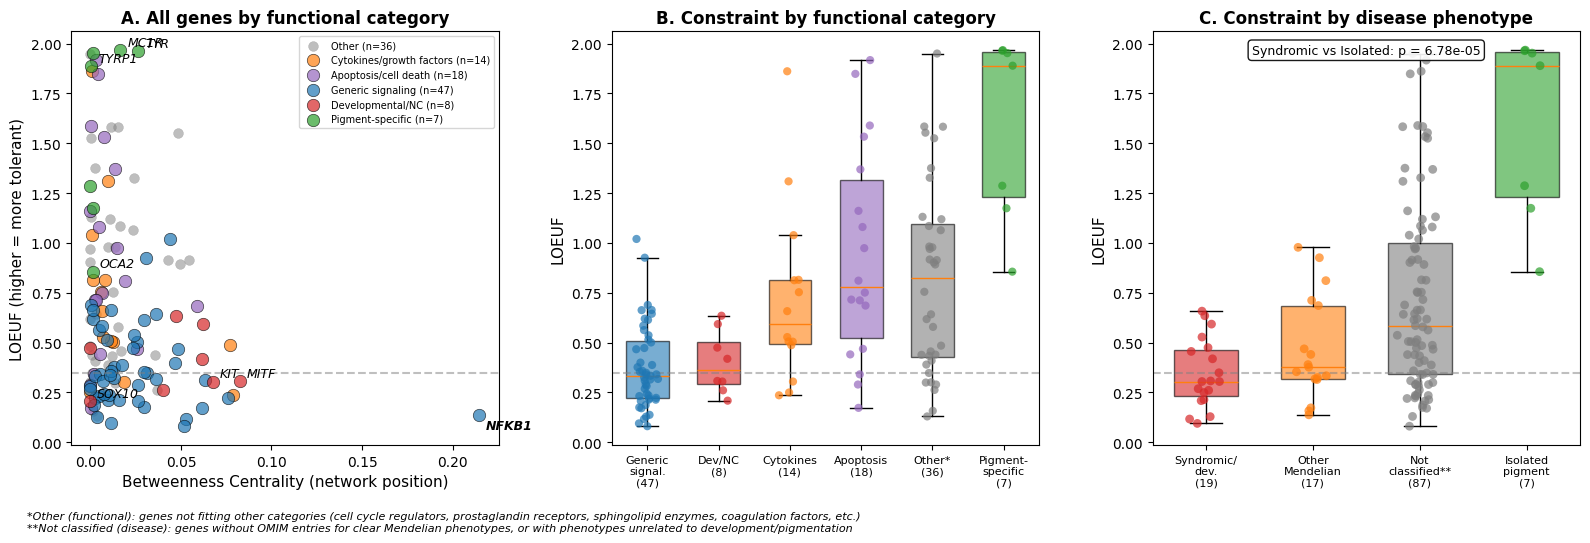


Figure saved!


In [17]:
# Colors for functional categories
func_colors = {
    'Pigment-specific': '#2ca02c',        # green
    'Developmental/NC': '#d62728',         # red
    'Generic signaling': '#1f77b4',        # blue
    'Apoptosis/cell death': '#9467bd',     # purple
    'Cytokines/growth factors': '#ff7f0e', # orange
    'Other': '#7f7f7f'                     # gray
}

# Colors for disease categories
disease_colors = {
    'Syndromic/developmental': '#d62728',
    'Isolated pigment': '#2ca02c',
    'Other Mendelian': '#ff7f0e',
    'Not classified': '#7f7f7f'
}

# Create 3-panel figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# ==========================================================================
# Panel A: Scatter plot - all genes by functional category
# ==========================================================================
ax1 = axes[0]

plot_order = ['Other', 'Cytokines/growth factors', 'Apoptosis/cell death', 
              'Generic signaling', 'Developmental/NC', 'Pigment-specific']

for cat in plot_order:
    subset = df[df['functional_category'] == cat]
    size = 50 if cat == 'Other' else 80
    alpha = 0.5 if cat == 'Other' else 0.7
    edge = 'gray' if cat == 'Other' else 'black'
    lw = 0.3 if cat == 'Other' else 0.5
    ax1.scatter(subset['BetweennessCentrality'], subset['LOEUF'],
                c=func_colors[cat], label=f"{cat} (n={len(subset)})",
                s=size, alpha=alpha, edgecolors=edge, linewidths=lw)

# Label key genes including NFKB1 (the high centrality outlier)
labels = ['MITF', 'MC1R', 'TYR', 'TYRP1', 'SOX10', 'KIT', 'OCA2', 'NFKB1']
for _, row in df[df['gene'].isin(labels)].iterrows():
    offset = (5, 3)
    if row['gene'] == 'NFKB1':
        offset = (5, -10)  # below the point
    ax1.annotate(row['gene'], (row['BetweennessCentrality'], row['LOEUF']),
                 xytext=offset, textcoords='offset points', fontsize=9, style='italic',
                 fontweight='bold' if row['gene'] == 'NFKB1' else 'normal')

ax1.set_xlabel('Betweenness Centrality (network position)', fontsize=11)
ax1.set_ylabel('LOEUF (higher = more tolerant)', fontsize=11)
ax1.set_title('A. All genes by functional category', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=7)
ax1.axhline(y=0.35, color='gray', linestyle='--', alpha=0.5)

# ==========================================================================
# Panel B: Boxplot by functional category
# ==========================================================================
ax2 = axes[1]

func_order = ['Generic signaling', 'Developmental/NC', 'Cytokines/growth factors', 
              'Apoptosis/cell death', 'Other', 'Pigment-specific']
func_data = [df[df['functional_category'] == cat]['LOEUF'].values for cat in func_order]
func_box_colors = [func_colors[cat] for cat in func_order]

bp2 = ax2.boxplot(func_data, positions=range(1, 7), widths=0.6, patch_artist=True, showfliers=False)
for patch, color in zip(bp2['boxes'], func_box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for i, (data, cat) in enumerate(zip(func_data, func_order)):
    np.random.seed(42)  # For reproducibility
    jitter = np.random.normal(0, 0.08, len(data))
    ax2.scatter(i + 1 + jitter, data, c=func_colors[cat], alpha=0.7, s=35,
                edgecolors='none', zorder=3)

# Count genes in each category
func_counts = [len(df[df['functional_category'] == cat]) for cat in func_order]
ax2.set_xticks(range(1, 7))
ax2.set_xticklabels([f'Generic\nsignal.\n({func_counts[0]})', f'Dev/NC\n({func_counts[1]})', 
                     f'Cytokines\n({func_counts[2]})', f'Apoptosis\n({func_counts[3]})',
                     f'Other*\n({func_counts[4]})', f'Pigment-\nspecific\n({func_counts[5]})'], fontsize=8)
ax2.set_ylabel('LOEUF', fontsize=11)
ax2.set_title('B. Constraint by functional category', fontsize=12, fontweight='bold')
ax2.axhline(y=0.35, color='gray', linestyle='--', alpha=0.5)

# ==========================================================================
# Panel C: Boxplot by disease phenotype
# ==========================================================================
ax3 = axes[2]

disease_order = ['Syndromic/developmental', 'Other Mendelian', 'Not classified', 'Isolated pigment']
disease_data = [df[df['disease_class'] == cat]['LOEUF'].values for cat in disease_order]
disease_box_colors = [disease_colors[cat] for cat in disease_order]

bp3 = ax3.boxplot(disease_data, positions=range(1, 5), widths=0.6, patch_artist=True, showfliers=False)
for patch, color in zip(bp3['boxes'], disease_box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for i, (data, cat) in enumerate(zip(disease_data, disease_order)):
    np.random.seed(42)  # For reproducibility
    jitter = np.random.normal(0, 0.08, len(data))
    ax3.scatter(i + 1 + jitter, data, c=disease_colors[cat], alpha=0.7, s=40,
                edgecolors='none', zorder=3)

# Count genes in each category
disease_counts = [len(df[df['disease_class'] == cat]) for cat in disease_order]
ax3.set_xticks(range(1, 5))
ax3.set_xticklabels([f'Syndromic/\ndev.\n({disease_counts[0]})', f'Other\nMendelian\n({disease_counts[1]})',
                     f'Not\nclassified**\n({disease_counts[2]})', f'Isolated\npigment\n({disease_counts[3]})'], fontsize=8)
ax3.set_ylabel('LOEUF', fontsize=11)
ax3.set_title('C. Constraint by disease phenotype', fontsize=12, fontweight='bold')
ax3.axhline(y=0.35, color='gray', linestyle='--', alpha=0.5)

# Stats annotation
ax3.text(0.5, 0.97, f'Syndromic vs Isolated: p = {p_disease:.2e}', 
         transform=ax3.transAxes, ha='center', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()

# Add footnotes
fig.text(0.02, 0.02, 
         "*Other (functional): genes not fitting other categories (cell cycle regulators, prostaglandin receptors, sphingolipid enzymes, coagulation factors, etc.)\n"
         "**Not classified (disease): genes without OMIM entries for clear Mendelian phenotypes, or with phenotypes unrelated to development/pigmentation",
         fontsize=8, style='italic', va='bottom')

plt.subplots_adjust(bottom=0.18)

# Save
plt.savefig(OUTPUT_DIR + 'network_composite.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_DIR + 'network_composite.pdf', bbox_inches='tight')
plt.show()

print("\nFigure saved!")

## 9. Export Data

In [13]:
# Export the full dataset
df_export = df[['gene', 'BetweennessCentrality', 'LOEUF', 'pLI', 
                'functional_category', 'disease_class']].copy()
df_export = df_export.sort_values(['functional_category', 'LOEUF'])
df_export.to_csv(OUTPUT_DIR + 'network_constraint_data.csv', index=False)

print("Saved: network_constraint_data.csv")
print(f"\nTotal genes: {len(df_export)}")
print(df_export.head(20))

Saved: network_constraint_data.csv

Total genes: 130
         gene  BetweennessCentrality  LOEUF           pLI  \
26      CFLAR               0.000446  0.173  9.996700e-01   
121      MCL1               0.000000  0.290  9.634900e-01   
14     BCL2L1               0.001714  0.341  9.366700e-01   
66        FAS               0.005041  0.441  8.117000e-01   
194      TP53               0.025518  0.469  5.323500e-01   
16      CASP3               0.058861  0.686  1.001700e-01   
13       BCL2               0.002648  0.712  5.590300e-01   
68      FASLG               0.003212  0.716  1.834500e-01   
11        BAX               0.006247  0.751  3.174600e-01   
17      CASP8               0.019349  0.811  3.723600e-06   
18      CASP9               0.014932  0.974  7.382600e-06   
46       DFFB               0.004969  1.080  1.134900e-05   
45       DFFA               0.000000  1.161  8.658500e-05   
10       BAK1               0.013534  1.369  7.402800e-06   
9         BAD               0.00

## 10. Summary

### Main Finding

Pigment-specific genes (TYR, TYRP1, DCT, MC1R, OCA2, PMEL, MLANA) are **uniquely tolerant** within the melanogenesis network. Everything else - generic signaling, developmental regulators, apoptosis, cytokines - is constrained.

### Interpretation

The only genes in this pathway where you can break the coding sequence without systemic consequences are the tissue-specific effectors that only make pigment. This suggests:

1. Adaptive coding variants in pigmentation should be enriched in tolerant (pigment-specific) genes
2. Constrained genes can only contribute to pigmentation variation via regulatory variants
3. "Purifying selection on melanogenesis" is really about selection on broadly important developmental genes

In [14]:
# Print final summary
print("="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"""
Analysis of {len(df)} genes in the Raghunath melanogenesis network:

BY FUNCTIONAL CATEGORY:
- Generic signaling (n={func_counts[0]}): median LOEUF = {np.median(func_data[0]):.3f}
- Developmental/NC (n={func_counts[1]}): median LOEUF = {np.median(func_data[1]):.3f}
- Pigment-specific (n={func_counts[5]}): median LOEUF = {np.median(func_data[5]):.3f}

BY DISEASE PHENOTYPE:
- Syndromic/developmental (n={disease_counts[0]}): median LOEUF = {np.median(syndromic):.3f}
- Isolated pigment (n={disease_counts[3]}): median LOEUF = {np.median(isolated):.3f}
- Mann-Whitney p = {p_disease:.2e}
- Complete separation: syndromic max ({syndromic.max():.3f}) < isolated min ({isolated.min():.3f})
""")

FINAL SUMMARY

Analysis of 130 genes in the Raghunath melanogenesis network:

BY FUNCTIONAL CATEGORY:
- Generic signaling (n=47): median LOEUF = 0.334
- Developmental/NC (n=8): median LOEUF = 0.363
- Pigment-specific (n=7): median LOEUF = 1.889

BY DISEASE PHENOTYPE:
- Syndromic/developmental (n=19): median LOEUF = 0.305
- Isolated pigment (n=7): median LOEUF = 1.889
- Mann-Whitney p = 6.78e-05
- Complete separation: syndromic max (0.658) < isolated min (0.856)

